# 🍜 VQA Ẩm Thực Việt Nam — Notebook Chạy Tuần Tự

**Cấu trúc ảnh đầu vào (đã phân thư mục theo món):**
```
data/raw_images/
├── pho/         ← tên thư mục = tên món
│   ├── 001.jpg
│   └── 002.jpg
├── bun_bo/
│   └── 001.jpg
└── com_tam/
    └── ...
```

**Thứ tự chạy:** Cell 1 → Cell 2 → ... → hết (mỗi cell sinh file cho cell tiếp theo)

## CELL 1 — Cài đặt thư viện

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — CÀI ĐẶT THƯ VIỆN
# ═══════════════════════════════════════════════════════════════
import subprocess, sys

PACKAGES = [
    'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
    'transformers>=4.37.0',
    'peft>=0.7.0',
    'accelerate>=0.26.0',
    'anthropic>=0.21.0',
    'Pillow>=10.0.0',
    'albumentations>=1.3.1',
    'opencv-python-headless',
    'nltk>=3.8.1',
    'rouge-score>=0.1.2',
    'bert-score>=0.3.13',
    'sacrebleu>=2.3.1',
    'underthesea>=6.8.0',
    'pandas numpy scikit-learn tqdm pyyaml matplotlib seaborn',
    'salesforce-lavis',
    'timm>=0.9.0',
]

for pkg in PACKAGES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split(), check=False)

import nltk
for d in ['punkt','wordnet','omw-1.4','punkt_tab']:
    nltk.download(d, quiet=True)

print('✅ Cài đặt xong!')

✅ Cài đặt xong!


## CELL 2 — Cấu hình toàn cục

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — TẠO Q&A TỪ ẢNH (OFFLINE, CHẠY CPU)
# Dùng BLIP Caption thay InstructBLIP
# ═══════════════════════════════════════════════════════════════

import os, json, torch
from PIL import Image
from tqdm import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration
from google.colab import drive
drive.mount('/content/drive')

RAW_IMAGE_DIR = '/content/drive/MyDrive/DL/dataset_small'
ANNOTATION_DIR = 'data/annotations'
os.makedirs(ANNOTATION_DIR, exist_ok=True)

DEVICE = 'cpu'
print("Device:", DEVICE)

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)

model.eval()


# ── Biến caption thành nhiều Q&A (TIẾNG VIỆT) ─────────────────
def caption_to_qa(caption):
    words = caption.lower().split()
    qa = []

    qa.append({"q": "Trong ảnh có gì?", "a": caption})

    if any(w in words for w in ["man", "woman", "person", "people"]):
        qa.append({"q": "Trong ảnh có ai?", "a": "một người"})

    if "dog" in words:
        qa.append({"q": "Trong ảnh có con vật gì?", "a": "chó"})
    if "cat" in words:
        qa.append({"q": "Trong ảnh có con vật gì?", "a": "mèo"})

    if any(c in words for c in ["red", "blue", "green", "yellow", "black", "white"]):
        qa.append({"q": "Màu nổi bật trong ảnh là gì?", "a": "nhiều màu"})

    if any(n in words for n in ["two", "three", "four"]):
        qa.append({"q": "Có bao nhiêu đối tượng chính?", "a": "nhiều"})

    if any(w in words for w in ["table", "chair", "bed", "sofa"]):
        qa.append({"q": "Bối cảnh trong ảnh là ở đâu?", "a": "trong nhà"})

    return qa


# ── Sinh Q&A từ ảnh ───────────────────────────────────────────
def generate_qa(image_path):
    image = Image.open(image_path).convert('RGB')
    inputs = processor(image, return_tensors="pt")

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption_to_qa(caption)


# ── Chạy toàn bộ thư mục ảnh ──────────────────────────────────
images = [f for f in os.listdir(RAW_IMAGE_DIR)
          if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

for img in tqdm(images):
    out_path = os.path.join(ANNOTATION_DIR, img + ".json")
    if os.path.exists(out_path):
        continue

    qa = generate_qa(os.path.join(RAW_IMAGE_DIR, img))

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(qa, f, indent=2, ensure_ascii=False)

print("✅ Hoàn tất sinh Q&A offline trên CPU!")

Mounted at /content/drive
Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


0it [00:00, ?it/s]

✅ Hoàn tất sinh Q&A offline trên CPU!


## CELL 3 — Quét ảnh & xây dựng danh sách (tận dụng tên thư mục làm nhãn)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — QUÉT ẢNH, TẬN DỤNG TÊN THƯ MỤC LÀM NHÃN
# ═══════════════════════════════════════════════════════════════
from pathlib import Path
from collections import defaultdict
from PIL import Image as PILImage

EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

def scan_images(root_dir: str):
    """
    Quét ảnh. Nếu ảnh nằm trong thư mục con → tên thư mục = nhãn món ăn.
    Nếu ảnh nằm thẳng ở root → nhãn = 'unknown'.
    Trả về list[dict] với keys: path, dish_label, image_id
    """
    records = []
    root = Path(root_dir)
    for p in sorted(root.rglob('*')):
        if p.suffix.lower() not in EXTS:
            continue
        # Tên thư mục cha (tên món)
        if p.parent == root:
            dish = 'unknown'
        else:
            dish = p.parent.name.replace('_', ' ').strip()
        records.append({
            'path': str(p),
            'dish_label': dish,
            'image_id': p.stem,
        })
    return records

IMAGE_RECORDS = scan_images(RAW_IMAGE_DIR)

# Thống kê
by_dish = defaultdict(list)
for r in IMAGE_RECORDS:
    by_dish[r['dish_label']].append(r)

print(f'Tổng ảnh tìm thấy : {len(IMAGE_RECORDS)}')
print(f'Số loại món ăn   : {len(by_dish)}')
print()
print(f'{"Món ăn":<30} {"Số ảnh":>8}')
print('-'*40)
for dish, imgs in sorted(by_dish.items(), key=lambda x: -len(x[1])):
    print(f'{dish:<30} {len(imgs):>8}')

assert len(IMAGE_RECORDS) >= 10, \
    f'Cần ít nhất 10 ảnh! Tìm thấy {len(IMAGE_RECORDS)}. Hãy copy ảnh vào {RAW_IMAGE_DIR}/'

# Lưu danh sách ảnh để các cell sau dùng
with open(f'{ANNOTATION_DIR}/_image_records.json', 'w', encoding='utf-8') as f:
    json.dump(IMAGE_RECORDS, f, ensure_ascii=False, indent=2)

print(f'\n✅ Đã lưu danh sách {len(IMAGE_RECORDS)} ảnh')

Tổng ảnh tìm thấy : 220
Số loại món ăn   : 27

Món ăn                           Số ảnh
----------------------------------------
Banh mi                              14
Banh canh                            12
Bun mam                              12
Banh gio                             10
Goi cuon                             10
Banh cuon                             9
Banh tet                              9
Banh xeo                              9
Bun dau mam tom                       9
Bun rieu                              9
Ca kho to                             9
Chao long                             9
Hu tieu                               9
Mi quang                              9
Banh duc                              8
Canh chua                             8
Banh trang nuong                      7
Bun thit nuong                        7
Banh bot loc                          6
Banh can                              6
Banh chung                            6
Banh pia                        

## CELL 4 — Auto-Annotation bằng Claude Vision (sinh Q&A từ ảnh thô)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — AUTO ANNOTATION OFFLINE (KHÔNG API)
# Dùng BLIP caption + dish_label để sinh Q&A tiếng Việt chuẩn type
# ═══════════════════════════════════════════════════════════════

import os, json, torch
from PIL import Image
from tqdm import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration

DEVICE = 'cpu'

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)

model.eval()


def caption_image(path):
    image = Image.open(path).convert('RGB')
    inputs = processor(image, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=50)
    return processor.decode(out[0], skip_special_tokens=True).lower()


def make_qa(dish_label, caption):
    qa = []

    # YES_NO
    qa.append({
        "question": f"Đây có phải món {dish_label} không?",
        "answer": "đúng",
        "type": "YES_NO"
    })
    qa.append({
        "question": "Món này có phải là món ăn Việt Nam không?",
        "answer": "đúng",
        "type": "YES_NO"
    })

    # IDENTIFY
    qa.append({
        "question": "Đây là món gì?",
        "answer": dish_label,
        "type": "IDENTIFY"
    })
    qa.append({
        "question": "Tên món ăn này là gì?",
        "answer": dish_label,
        "type": "IDENTIFY"
    })

    # COUNT
    qa.append({
        "question": "Có bao nhiêu phần ăn trong ảnh?",
        "answer": "một",
        "type": "COUNT"
    })

    # ATTRIBUTE
    qa.append({
        "question": "Màu sắc chính của món là gì?",
        "answer": "nhiều màu",
        "type": "ATTRIBUTE"
    })
    qa.append({
        "question": "Món ăn trông như thế nào?",
        "answer": "hấp dẫn",
        "type": "ATTRIBUTE"
    })

    # INGREDIENT
    qa.append({
        "question": f"Món {dish_label} thường có nguyên liệu gì?",
        "answer": "nhiều nguyên liệu",
        "type": "INGREDIENT"
    })
    qa.append({
        "question": "Món này có rau không?",
        "answer": "có",
        "type": "INGREDIENT"
    })

    # SPATIAL
    qa.append({
        "question": "Món ăn được đựng trong gì?",
        "answer": "bát hoặc đĩa",
        "type": "SPATIAL"
    })

    return qa


RAW_ANNOTATIONS = []

for rec in tqdm(IMAGE_RECORDS, desc="Annotating offline"):
    caption = caption_image(rec['path'])
    qa_pairs = make_qa(rec['dish_label'], caption)

    RAW_ANNOTATIONS.append({
        'image_path': rec['path'],
        'image_id': rec['image_id'],
        'dish_label': rec['dish_label'],
        'dish_name': rec['dish_label'],
        'qa_pairs': qa_pairs
    })

print(f"\n✅ Annotated offline: {len(RAW_ANNOTATIONS)} ảnh")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


✅ Annotated offline: 220 ảnh


## CELL 5 — Paraphrase câu hỏi (tăng cường văn bản)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — PARAPHRASE CÂU HỎI (OFFLINE, KHÔNG API)
# ═══════════════════════════════════════════════════════════════

import json, os, random

PARA_CACHE_FILE = f'{ANNOTATION_DIR}/_paraphrase_cache.json'

para_cache = {}
if os.path.exists(PARA_CACHE_FILE):
    with open(PARA_CACHE_FILE, encoding='utf-8') as f:
        para_cache = json.load(f)

print(f'Paraphrase cache hiện có: {len(para_cache)} câu')


# ── Tập luật paraphrase tiếng Việt ────────────────────────────
REWRITE_RULES = [
    ("Trong ảnh", "Hình này"),
    ("Trong ảnh", "Bức hình"),
    ("Đây là", "Đây chính là"),
    ("Có bao nhiêu", "Số lượng"),
    ("Món ăn", "Món này"),
    ("Màu sắc", "Màu chủ đạo"),
    ("được đựng trong", "để trong"),
    ("là gì", "là món gì"),
]


def paraphrase_vi(q, n=3):
    paras = set()
    for _ in range(n * 3):
        new_q = q
        for a, b in REWRITE_RULES:
            if random.random() < 0.5:
                new_q = new_q.replace(a, b)
        if new_q != q:
            paras.add(new_q)
        if len(paras) >= n:
            break
    return list(paras)


# ── Thu thập câu hỏi từ RAW_ANNOTATIONS ──────────────────────
all_questions = list(set(
    qa['question']
    for ann in RAW_ANNOTATIONS
    for qa in ann['qa_pairs']
))

print(f'Tổng câu hỏi cần paraphrase: {len(all_questions)}')


# ── Tạo paraphrase cache ──────────────────────────────────────
for q in all_questions:
    if q not in para_cache:
        para_cache[q] = paraphrase_vi(q, n=3)

with open(PARA_CACHE_FILE, 'w', encoding='utf-8') as f:
    json.dump(para_cache, f, ensure_ascii=False, indent=2)

print(f'\n✅ Đã tạo paraphrase offline cho {len(para_cache)} câu')

Paraphrase cache hiện có: 0 câu
Tổng câu hỏi cần paraphrase: 62

✅ Đã tạo paraphrase offline cho 62 câu


## CELL 6 — Xây dựng VQA Dataset (flatten + paraphrase + augment ảnh)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — XÂY DỰNG VQA DATASET PHẲNG + TRANSFORMS ĐÚNG API MỚI
# ═══════════════════════════════════════════════════════════════
import json
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(split: str):
    if split == 'train':
        return A.Compose([
            A.RandomResizedCrop(
                size=(IMAGE_SIZE, IMAGE_SIZE),   # ⭐ API mới
                scale=(0.8, 1.0),
                ratio=(0.75, 1.33),
            ),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=15, p=0.4),
            A.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.2, p=0.5),
            A.GaussNoise(var_limit=(10, 50), p=0.2),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2(),                      # ⭐ bắt buộc
        ])
    else:
        return A.Compose([
            A.Resize(
                height=IMAGE_SIZE,
                width=IMAGE_SIZE
            ),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2(),                      # ⭐ bắt buộc
        ])


def build_flat_vqa(annotations, para_cache, include_paraphrase=True):
    records = []
    sid = 0

    for ann in annotations:
        for qa in ann['qa_pairs']:
            base = {
                'id': sid,
                'image_id': ann['image_id'],
                'image_path': ann['image_path'],
                'dish_label': ann['dish_label'],
                'dish_name':  ann.get('dish_name', ann['dish_label']),
                'question': qa['question'],
                'answer': qa['answer'],
                'answer_type': qa['type'],
                'augmented': False,
            }
            records.append(base)
            sid += 1

            if include_paraphrase:
                for pq in para_cache.get(qa['question'], []):
                    records.append({
                        **base,
                        'id': sid,
                        'question': pq,
                        'augmented': True,
                        'original_question': qa['question']
                    })
                    sid += 1

    return records


VQA_ALL = build_flat_vqa(RAW_ANNOTATIONS, para_cache, include_paraphrase=True)

with open(f'{ANNOTATION_DIR}/vqa_all.json', 'w', encoding='utf-8') as f:
    json.dump(VQA_ALL, f, ensure_ascii=False, indent=2)


# ── Thống kê ──────────────────────────────────────────────────
from collections import Counter
type_counts = Counter(r['answer_type'] for r in VQA_ALL)

print(f'Tổng mẫu VQA : {len(VQA_ALL):,}')
print(f'Số ảnh        : {len(set(r["image_id"] for r in VQA_ALL)):,}')
print(f'Mẫu gốc       : {sum(1 for r in VQA_ALL if not r["augmented"]):,}')
print(f'Mẫu paraphrase: {sum(1 for r in VQA_ALL if r["augmented"]):,}\n')

for t, c in type_counts.most_common():
    bar = '█' * int(c / len(VQA_ALL) * 40)
    print(f'  {t:<12} {c:>5}  {bar}')

print(f'\n✅ Dataset phẳng đã lưu → {ANNOTATION_DIR}/vqa_all.json')

Tổng mẫu VQA : 4,400
Số ảnh        : 186
Mẫu gốc       : 2,200
Mẫu paraphrase: 2,200

  ATTRIBUTE     1320  ████████████
  IDENTIFY       880  ████████
  SPATIAL        880  ████████
  YES_NO         440  ████
  COUNT          440  ████
  INGREDIENT     440  ████

✅ Dataset phẳng đã lưu → data/annotations/vqa_all.json


## CELL 7 — Chia train/val/test (image-level, tránh data leakage)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — IMAGE-LEVEL STRATIFIED SPLIT (TRAIN ≈ 2100 Q&A)
# ═══════════════════════════════════════════════════════════════

import random
from collections import defaultdict
import json, os

SEED = 42
PROCESSED_DIR = 'data/processed'
TARGET_TRAIN_SAMPLES = 2100   # ⭐ yêu cầu mới

def stratified_image_split(vqa_data, train_r=0.8, val_r=0.1, test_r=0.1, seed=SEED):
    rng = random.Random(seed)

    # ── UNIQUE IMAGE ──────────────────────────────────────────
    image_records = {}
    for r in vqa_data:
        image_records.setdefault(r['image_id'], r['dish_label'])

    # ── Gom ảnh theo dish ─────────────────────────────────────
    by_dish = defaultdict(list)
    for img_id, dish in image_records.items():
        by_dish[dish].append(img_id)

    train_ids, val_ids, test_ids = set(), set(), set()

    # ── Split trong từng dish ─────────────────────────────────
    for dish, imgs in by_dish.items():
        rng.shuffle(imgs)
        n = len(imgs)

        n_test = max(1, round(n * test_r))
        n_val  = max(1, round(n * val_r))

        test_ids.update(imgs[:n_test])
        val_ids.update(imgs[n_test:n_test+n_val])
        train_ids.update(imgs[n_test+n_val:])

    # ── Đảm bảo test >= 50 ảnh ───────────────────────────────
    if len(test_ids) < 50:
        need = 50 - len(test_ids)
        pool = list(train_ids)
        rng.shuffle(pool)
        moved = pool[:need]
        test_ids.update(moved)
        train_ids.difference_update(moved)

    # ── GIẢM TRAIN XUỐNG ≈ 2100 Q&A (THEO IMAGE, STRATIFIED) ─
    img2records = defaultdict(list)
    for r in vqa_data:
        img2records[r['image_id']].append(r)

    # shuffle ảnh train
    train_img_list = list(train_ids)
    rng.shuffle(train_img_list)

    selected_imgs = set()
    total = 0

    for img_id in train_img_list:
        selected_imgs.add(img_id)
        total += len(img2records[img_id])
        if total >= TARGET_TRAIN_SAMPLES:
            break

    train_ids = selected_imgs

    # ── Build dataset ─────────────────────────────────────────
    train = [r for r in vqa_data if r['image_id'] in train_ids]
    val   = [r for r in vqa_data if r['image_id'] in val_ids]
    test  = [r for r in vqa_data
             if r['image_id'] in test_ids and not r.get('augmented')]

    return train, val, test


# ── Thực hiện split ───────────────────────────────────────────
TRAIN_DATA, VAL_DATA, TEST_DATA = stratified_image_split(VQA_ALL)


# ── Kiểm tra leakage ─────────────────────────────────────────
def get_imgs(data):
    return set(r['image_id'] for r in data)

assert get_imgs(TRAIN_DATA).isdisjoint(get_imgs(TEST_DATA))
assert get_imgs(VAL_DATA).isdisjoint(get_imgs(TEST_DATA))
assert get_imgs(TRAIN_DATA).isdisjoint(get_imgs(VAL_DATA))

print("✅ Không có image leakage giữa các tập")


# ── Lưu file ─────────────────────────────────────────────────
os.makedirs(PROCESSED_DIR, exist_ok=True)

for name, data in [('train', TRAIN_DATA),
                   ('val', VAL_DATA),
                   ('test', TEST_DATA)]:
    with open(f'{PROCESSED_DIR}/{name}.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

print(f'\nTrain: {len(TRAIN_DATA):,} | Val: {len(VAL_DATA):,} | Test: {len(TEST_DATA):,}')
print(f'🎯 Train target ≈ {TARGET_TRAIN_SAMPLES} samples')

✅ Không có image leakage giữa các tập

Train: 2,100 | Val: 620 | Test: 580
🎯 Train target ≈ 2100 samples


## CELL 8 — Xây dựng Vocabulary (Answer + Question)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — BUILD VOCAB & ENCODE DATA (CHUẨN cho VQA + Collate PAD)
# ĐÃ FIX: decode_seq cho generation ở eval
# ═══════════════════════════════════════════════════════════════
import json, os
from collections import Counter

PROCESSED_DIR = 'data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

MAX_A_LEN = 12
MAX_Q_LEN = 32


class Vocabulary:
    PAD, UNK, SOS, EOS = '<pad>', '<unk>', '<sos>', '<eos>'
    SPECIAL = [PAD, UNK, SOS, EOS]

    def __init__(self, name='vocab', min_freq=1):
        self.name = name
        self.min_freq = min_freq
        self.w2i = {}
        self.i2w = {}

    # ── Build vocab ───────────────────────────────────────────
    def build(self, texts, as_phrase=False):
        counter = Counter()

        for t in texts:
            if as_phrase:
                counter.update([t.strip().lower()])
            else:
                counter.update(t.lower().strip().split())

        # Special tokens
        for i, tok in enumerate(self.SPECIAL):
            self.w2i[tok] = i
            self.i2w[i] = tok

        # Normal tokens
        for tok, cnt in counter.items():
            if cnt < self.min_freq or tok in self.w2i:
                continue
            idx = len(self.w2i)
            self.w2i[tok] = idx
            self.i2w[idx] = tok

    # ── Encode phrase (classification label) ─────────────────
    def encode_phrase(self, text):
        return self.w2i.get(text.strip().lower(), self.w2i[self.UNK])

    # ── Encode answer sequence (không pad cứng) ──────────────
    def encode_answer_tokens(self, text):
        tokens = [self.SOS] + text.lower().strip().split()[:MAX_A_LEN-2] + [self.EOS]
        return [self.w2i.get(t, self.w2i[self.UNK]) for t in tokens]

    # ── Encode question (không pad cứng) ──────────────────────
    def encode_question(self, text):
        tokens = text.lower().strip().split()[:MAX_Q_LEN]
        return [self.w2i.get(t, self.w2i[self.UNK]) for t in tokens]

    # ── ⭐ QUAN TRỌNG: Decode cho generation ─────────────────
    def decode_seq(self, ids):
        words = []
        for i in ids:
            if i == self.pad_idx:
                continue
            w = self.i2w.get(i, '')
            if w in [self.SOS, self.EOS]:
                continue
            words.append(w)
        return ' '.join(words).strip()

    @property
    def pad_idx(self):
        return self.w2i.get(self.PAD, 0)

    def save(self, path):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({
                'w2i': self.w2i,
                'i2w': {str(k): v for k, v in self.i2w.items()},
                'name': self.name
            }, f, ensure_ascii=False, indent=2)

    def __len__(self):
        return len(self.w2i)


# ═══════════════════════════════════════════════════════════════
# BUILD VOCAB CHỈ TỪ TRAIN (QUAN TRỌNG)
# ═══════════════════════════════════════════════════════════════
train_answers = [r['answer'] for r in TRAIN_DATA]
train_questions = [r['question'] for r in TRAIN_DATA]

ANS_PHRASE_VOCAB = Vocabulary('answer_phrase')
ANS_PHRASE_VOCAB.build(train_answers, as_phrase=True)
ANS_PHRASE_VOCAB.save(f'{PROCESSED_DIR}/vocab_answer_phrase.json')

ANS_TOKEN_VOCAB = Vocabulary('answer_token')
ANS_TOKEN_VOCAB.build(train_answers, as_phrase=False)
ANS_TOKEN_VOCAB.save(f'{PROCESSED_DIR}/vocab_answer_token.json')

Q_VOCAB = Vocabulary('question')
Q_VOCAB.build(train_questions, as_phrase=False)
Q_VOCAB.save(f'{PROCESSED_DIR}/vocab_question.json')


# ═══════════════════════════════════════════════════════════════
# ENCODE DATA (không pad — để collate_fn xử lý)
# ═══════════════════════════════════════════════════════════════
def encode_dataset(data_list):
    for r in data_list:
        r['answer_idx'] = ANS_PHRASE_VOCAB.encode_phrase(r['answer'])
        r['answer_token_ids'] = ANS_TOKEN_VOCAB.encode_answer_tokens(r['answer'])
        r['question_ids'] = Q_VOCAB.encode_question(r['question'])

for data_list in [TRAIN_DATA, VAL_DATA, TEST_DATA]:
    encode_dataset(data_list)


# ═══════════════════════════════════════════════════════════════
# SAVE ENCODED DATA
# ═══════════════════════════════════════════════════════════════
for name, data in [('train', TRAIN_DATA),
                   ('val', VAL_DATA),
                   ('test', TEST_DATA)]:
    with open(f'{PROCESSED_DIR}/{name}.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


print(f'Answer phrase vocab : {len(ANS_PHRASE_VOCAB):,}')
print(f'Answer token vocab  : {len(ANS_TOKEN_VOCAB):,}')
print(f'Question vocab      : {len(Q_VOCAB):,}')
print('✅ Vocabulary & Encoding xong — tương thích hoàn hảo với CELL 9 & Trainer!')

Answer phrase vocab : 37
Answer token vocab  : 52
Question vocab      : 76
✅ Vocabulary & Encoding xong — tương thích hoàn hảo với CELL 9 & Trainer!


## CELL 9 — PyTorch Dataset & DataLoader

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — PYTORCH DATASET & DATALOADER (CHUẨN VQA, NOTEBOOK SAFE)
# ═══════════════════════════════════════════════════════════════
import torch
import numpy as np
from PIL import Image as PILImage
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

IMAGE_SIZE = 224
BATCH_SIZE = 32

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


class VQADataset(Dataset):
    def __init__(self, data: list, split: str = 'train'):
        self.data = data
        self.tfm  = get_transforms(split)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        r = self.data[idx]

        # ── Load image an toàn ────────────────────────────────
        try:
            img = np.array(PILImage.open(r['image_path']).convert('RGB'))
        except Exception:
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        img = self.tfm(image=img)['image']  # (3,H,W)

        return {
            'image':         img,
            'question_ids':  torch.tensor(r['question_ids'],     dtype=torch.long),
            'answer_tokens': torch.tensor(r['answer_token_ids'], dtype=torch.long),
            'answer_idx':    torch.tensor(r['answer_idx'],       dtype=torch.long),
            'question_text': r['question'],
            'answer_text':   r['answer'],
            'image_id':      r['image_id'],
        }


# ── COLLATE PAD (bắt buộc cho VQA) ───────────────────────────
def vqa_collate(batch):
    images = torch.stack([b['image'] for b in batch])

    q_ids = [b['question_ids'] for b in batch]
    a_tok = [b['answer_tokens'] for b in batch]

    q_pad = pad_sequence(q_ids, batch_first=True, padding_value=0)
    a_pad = pad_sequence(a_tok, batch_first=True, padding_value=0)

    q_len = torch.tensor([len(q.nonzero()) for q in q_ids], dtype=torch.long)
    ans_idx = torch.stack([b['answer_idx'] for b in batch])

    return {
        'image': images,
        'question_ids': q_pad,
        'question_len': q_len,
        'answer_tokens': a_pad,
        'answer_idx': ans_idx,
        'question_text': [b['question_text'] for b in batch],
        'answer_text':   [b['answer_text'] for b in batch],
        'image_id':      [b['image_id'] for b in batch],
    }


# ── BUILD LOADERS (Notebook-safe: num_workers=0) ─────────────
def build_loaders(batch_size=BATCH_SIZE):
    loaders = {}

    for split, data in [
        ('train', TRAIN_DATA),
        ('val',   VAL_DATA),
        ('test',  TEST_DATA)
    ]:
        ds = VQADataset(data, split)

        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=0,  # ⭐ quan trọng cho Notebook/macOS/Windows
            pin_memory=(DEVICE.type == 'cuda'),
            drop_last=(split == 'train'),
            collate_fn=vqa_collate,
        )

    return loaders


# ── TEST ─────────────────────────────────────────────────────
LOADERS = build_loaders()
batch = next(iter(LOADERS['train']))

print('image:', batch['image'].shape)
print('question_ids:', batch['question_ids'].shape)
print('answer_tokens:', batch['answer_tokens'].shape)
print('question_len:', batch['question_len'].shape)
print('answer_idx:', batch['answer_idx'].shape)
print('✅ DataLoader chuẩn VQA!')

Device: cuda


/tmp/ipykernel_876/2499520746.py:20: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


image: torch.Size([32, 3, 224, 224])
question_ids: torch.Size([32, 10])
answer_tokens: torch.Size([32, 5])
question_len: torch.Size([32])
answer_idx: torch.Size([32])
✅ DataLoader chuẩn VQA!


## CELL 10 — Định nghĩa mô hình Direction A (Image Encoder, Text Encoder, Co-Attention, Decoder)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — KIẾN TRÚC MÔ HÌNH DIRECTION A
# ═══════════════════════════════════════════════════════════════
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ── Image Encoder (ResNet50 pretrained) ────────────────────────
class ImageEncoder(nn.Module):
    def __init__(self, out_dim=512, freeze_until=6):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Bỏ avg-pool + fc → lấy spatial feature map (B,2048,7,7)
        self.backbone = nn.Sequential(*list(base.children())[:-2])
        # Đóng băng n layer đầu
        for i, child in enumerate(self.backbone.children()):
            if i < freeze_until:
                for p in child.parameters(): p.requires_grad = False
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.global_proj = nn.Sequential(nn.Linear(2048, out_dim), nn.LayerNorm(out_dim), nn.ReLU())
        self.spatial_proj = nn.Sequential(nn.Conv2d(2048, out_dim, 1), nn.ReLU())

    def forward(self, x):
        feat = self.backbone(x)                        # (B,2048,7,7)
        g = self.global_pool(feat).flatten(1)         # (B,2048)
        g = self.global_proj(g)                       # (B,D)
        s = self.spatial_proj(feat)                   # (B,D,7,7)
        B,D,H,W = s.shape
        s = s.view(B,D,H*W).permute(0,2,1)           # (B,49,D)
        return g, s

# ── Text Encoder (PhoBERT) ─────────────────────────────────────
class PhoBERTEncoder(nn.Module):
    def __init__(self, out_dim=512, freeze=False):
        super().__init__()
        from transformers import AutoModel
        self.bert = AutoModel.from_pretrained('vinai/phobert-base')
        if freeze:
            for p in self.bert.parameters(): p.requires_grad = False
        self.proj = nn.Sequential(nn.Linear(768, out_dim), nn.LayerNorm(out_dim), nn.ReLU())

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls  = self.proj(out.last_hidden_state[:, 0])   # (B,D)
        toks = self.proj(out.last_hidden_state)          # (B,L,D)
        return cls, toks

# ── Text Encoder (BiLSTM — thay thế khi không có GPU đủ) ───────
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, out_dim=512, num_layers=2, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.proj = nn.Sequential(nn.Linear(hidden_dim*2, out_dim), nn.LayerNorm(out_dim), nn.ReLU())

    def forward(self, input_ids, lengths):
        emb = self.emb(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, (h,_) = self.lstm(packed)
        out,_ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        h_cat = torch.cat([h[-2],h[-1]], dim=1)  # (B,2H)
        return self.proj(h_cat), self.proj(out)   # (B,D), (B,L,D)

# ── Co-Attention Fusion ────────────────────────────────────────
class CoAttentionFusion(nn.Module):
    def __init__(self, d=512, heads=8, dropout=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.n1  = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d*2,d), nn.GELU(), nn.Dropout(dropout), nn.Linear(d,d))
        self.n3  = nn.LayerNorm(d)

    def forward(self, img_s, txt_s, img_g, txt_g):
        ia,_ = self.i2t(img_s, txt_s, txt_s);  ia = self.n1(img_s+ia).mean(1)  # (B,D)
        ta,_ = self.t2i(txt_s, img_s, img_s);  ta = self.n2(txt_s+ta).mean(1)  # (B,D)
        fused = self.ffn(torch.cat([ia+img_g, ta+txt_g], dim=1))
        return self.n3(fused)  # (B,D)

# ── A1: LSTM Decoder ───────────────────────────────────────────
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, d=512, embed_dim=256, num_layers=2, dropout=0.3, tf_ratio=0.5):
        super().__init__()
        self.tf_ratio = tf_ratio
        self.num_layers = num_layers
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.h0   = nn.Linear(d, d)
        self.lstm = nn.LSTM(embed_dim+d, d, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.out  = nn.Linear(d, vocab_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, ctx, tgt_tokens=None, max_len=MAX_A_LEN):
        B, D = ctx.shape; device = ctx.device
        h0 = self.h0(ctx).unsqueeze(0).repeat(self.num_layers,1,1)
        c0 = torch.zeros_like(h0)
        hid = (h0, c0)
        inp = torch.full((B,1), ANS_TOKEN_VOCAB.w2i['<sos>'], dtype=torch.long, device=device)
        logits = []
        import random as _r
        T = tgt_tokens.size(1) if tgt_tokens is not None else max_len
        for t in range(T):
            e   = self.drop(self.emb(inp))                    # (B,1,E)
            c   = ctx.unsqueeze(1)                             # (B,1,D)
            o,hid = self.lstm(torch.cat([e,c],2), hid)        # (B,1,D)
            lg  = self.out(self.drop(o))                       # (B,1,V)
            logits.append(lg)
            if tgt_tokens is not None and _r.random() < self.tf_ratio:
                inp = tgt_tokens[:,t:t+1]
            else:
                inp = lg.argmax(-1)
        return torch.cat(logits, 1)   # (B,T,V)

    @torch.no_grad()
    def generate(self, ctx, max_len=MAX_A_LEN):
        B,D = ctx.shape; device = ctx.device
        h0 = self.h0(ctx).unsqueeze(0).repeat(self.num_layers,1,1)
        hid = (h0, torch.zeros_like(h0))
        inp = torch.full((B,1), ANS_TOKEN_VOCAB.w2i['<sos>'], dtype=torch.long, device=device)
        eos = ANS_TOKEN_VOCAB.w2i['<eos>']
        out = []
        for _ in range(max_len):
            e   = self.emb(inp)
            o,hid = self.lstm(torch.cat([e, ctx.unsqueeze(1)],2), hid)
            t   = self.out(o).argmax(-1)   # (B,1)
            out.append(t)
            inp = t
        return torch.cat(out, 1)   # (B, max_len)

# ── A2: Transformer Decoder ────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=64, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0,max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000)/d))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self,x): return self.drop(x + self.pe[:,:x.size(1)])

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d=512, nhead=8, layers=4, ff=2048, drop=0.1):
        super().__init__()
        self.emb   = nn.Embedding(vocab_size, d, padding_idx=0)
        self.pe    = PositionalEncoding(d, max_len=64, drop=drop)
        self.mproj = nn.Linear(d, d)
        dec_layer  = nn.TransformerDecoderLayer(d, nhead, ff, drop, batch_first=True)
        self.dec   = nn.TransformerDecoder(dec_layer, layers)
        self.out   = nn.Linear(d, vocab_size)

    def _causal_mask(self, sz, device):
        return torch.triu(torch.ones(sz,sz,device=device),1).bool()

    def forward(self, ctx, tgt_tokens):    # ctx:(B,D)  tgt:(B,L)
        mem = self.mproj(ctx).unsqueeze(1)             # (B,1,D)
        tgt = self.pe(self.emb(tgt_tokens))            # (B,L,D)
        mask= self._causal_mask(tgt.size(1), ctx.device)
        o   = self.dec(tgt, mem, tgt_mask=mask, tgt_is_causal=True)
        return self.out(o)                             # (B,L,V)

    @torch.no_grad()
    def generate(self, ctx, max_len=MAX_A_LEN):
        B    = ctx.size(0); device = ctx.device
        mem  = self.mproj(ctx).unsqueeze(1)
        sos  = ANS_TOKEN_VOCAB.w2i['<sos>']
        eos  = ANS_TOKEN_VOCAB.w2i['<eos>']
        toks = torch.full((B,1), sos, dtype=torch.long, device=device)
        for _ in range(max_len-1):
            tgt  = self.pe(self.emb(toks))
            mask = self._causal_mask(toks.size(1), device)
            o    = self.dec(tgt, mem, tgt_mask=mask, tgt_is_causal=True)
            nxt  = self.out(o[:,-1:]).argmax(-1)       # (B,1)
            toks = torch.cat([toks,nxt],1)
            if (nxt.squeeze(1)==eos).all(): break
        return toks[:,1:]   # bỏ SOS

print('✅ Đã định nghĩa: ImageEncoder, PhoBERTEncoder, BiLSTMEncoder')
print('✅ Đã định nghĩa: CoAttentionFusion')
print('✅ Đã định nghĩa: LSTMDecoder (A1), TransformerDecoder (A2)')

✅ Đã định nghĩa: ImageEncoder, PhoBERTEncoder, BiLSTMEncoder
✅ Đã định nghĩa: CoAttentionFusion
✅ Đã định nghĩa: LSTMDecoder (A1), TransformerDecoder (A2)


## CELL 11 — Full VQA Model A (ghép các thành phần)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — FULL VQA MODEL A (ghép thành phần)
# ═══════════════════════════════════════════════════════════════
from transformers import AutoTokenizer
FUSION_DIM = 512
TEACHER_FORCING = 0.5
MAX_Q_LEN = 32

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("DEVICE:", DEVICE)
print("FUSION_DIM:", FUSION_DIM)

# PhoBERT tokenizer (dùng để encode câu hỏi cho PhoBERT branch)
PHOBERT_TOKENIZER = AutoTokenizer.from_pretrained('vinai/phobert-base')

class VQAModelA(nn.Module):
    """
    decoder_type: 'lstm' → A1   |   'transformer' → A2
    text_encoder: 'phobert' → PhoBERT   |   'bilstm' → BiLSTM
    """
    def __init__(self, decoder_type='lstm', text_encoder='phobert', d=FUSION_DIM):
        super().__init__()
        self.decoder_type = decoder_type
        self.text_type    = text_encoder

        self.img_enc = ImageEncoder(out_dim=d, freeze_until=6)

        if text_encoder == 'phobert':
            self.txt_enc = PhoBERTEncoder(out_dim=d, freeze=False)
        else:
            self.txt_enc = BiLSTMEncoder(len(Q_VOCAB), embed_dim=256,
                                         hidden_dim=256, out_dim=d, num_layers=2)

        self.fusion = CoAttentionFusion(d=d, heads=8, dropout=0.1)

        # Classification head (dự đoán answer class)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d, len(ANS_PHRASE_VOCAB)))

        # Generation decoder
        V = len(ANS_TOKEN_VOCAB)
        if decoder_type == 'lstm':
            self.decoder = LSTMDecoder(V, d=d, embed_dim=256, num_layers=2,
                                       dropout=0.3, tf_ratio=TEACHER_FORCING)
        else:
            self.decoder = TransformerDecoder(V, d=d, nhead=8, layers=4, ff=2048)

    def _encode_question(self, batch):
        if self.text_type == 'phobert':
            # Tokenize bằng PhoBERT tokenizer (tốt hơn word-level)
            encoded = PHOBERT_TOKENIZER(
                batch['question_text'], padding=True, truncation=True,
                max_length=MAX_Q_LEN, return_tensors='pt'
            )
            ids  = encoded['input_ids'].to(DEVICE)
            mask = encoded['attention_mask'].to(DEVICE)
            return self.txt_enc(ids, mask)
        else:
            return self.txt_enc(batch['question_ids'], batch['question_len'])

    def forward(self, batch):
        img_g, img_s = self.img_enc(batch['image'])
        txt_g, txt_s = self._encode_question(batch)
        ctx = self.fusion(img_s, txt_s, img_g, txt_g)          # (B,D)
        cls_logits = self.classifier(ctx)                       # (B, num_classes)

        gen_logits = None
        if self.decoder_type == 'lstm':
            gen_logits = self.decoder(ctx, batch.get('answer_tokens'))
        else:
            if 'answer_tokens' in batch:
                gen_logits = self.decoder(ctx, batch['answer_tokens'][:, :-1])

        return {'cls': cls_logits, 'gen': gen_logits, 'ctx': ctx}

    @torch.no_grad()
    def generate_text(self, batch):
        img_g, img_s = self.img_enc(batch['image'])
        txt_g, txt_s = self._encode_question(batch)
        ctx = self.fusion(img_s, txt_s, img_g, txt_g)
        token_ids = self.decoder.generate(ctx)                  # (B, gen_len)
        results = []
        for row in token_ids.tolist():
            results.append(ANS_TOKEN_VOCAB.decode_seq(row))
        return results

# Kiểm tra
test_model = VQAModelA(decoder_type='lstm', text_encoder='bilstm').to(DEVICE)
test_batch  = {k: v.to(DEVICE) if isinstance(v,torch.Tensor) else v for k,v in batch.items()}
out = test_model(test_batch)
print('cls logits:', out['cls'].shape)
print('gen logits:', out['gen'].shape if out['gen'] is not None else None)
del test_model
print('✅ VQAModelA hoạt động!')

DEVICE: cuda
FUSION_DIM: 512


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


cls logits: torch.Size([32, 37])
gen logits: torch.Size([32, 5, 52])
✅ VQAModelA hoạt động!


## CELL 12 — Loss Function & Trainer

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — LOSS FUNCTION & TRAINING ENGINE (SELF-CONTAINED)
# ═══════════════════════════════════════════════════════════════
import os, json, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

# ====== SAFE CONFIG (nếu chưa có) ======
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS        = 15
LR            = 2e-4
WEIGHT_DECAY  = 1e-4
USE_AMP       = True
GRAD_CLIP     = 1.0
PATIENCE      = 5
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("DEVICE:", DEVICE)

# ====== LOSS ======
class VQALoss(nn.Module):
    """Classification loss + Generation loss (50/50)."""
    def __init__(self, alpha=0.5, pad_idx=0):
        super().__init__()
        self.alpha   = alpha
        self.cls_fn  = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.gen_fn  = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=0.1)

    def forward(self, cls_logits, gen_logits, ans_idx, ans_tokens):
        L_cls = self.cls_fn(cls_logits, ans_idx)

        L_gen = torch.tensor(0., device=cls_logits.device)
        if gen_logits is not None:
            B,T,V = gen_logits.shape
            tgt = ans_tokens[:, 1:T+1].contiguous()
            L_gen = self.gen_fn(
                gen_logits[:, :tgt.size(1)].reshape(-1, V),
                tgt.reshape(-1)
            )

        total = self.alpha*L_cls + (1-self.alpha)*L_gen
        return total, L_cls.item(), L_gen.item()


def vqa_accuracy(preds, gts):
    return sum(p.strip().lower()==g.strip().lower() for p,g in zip(preds,gts)) / max(len(preds),1)

# ====== TRAINER ======
class Trainer:
    def __init__(self, model_name, decoder_type='lstm', text_enc='phobert'):
        self.name     = model_name
        self.model    = VQAModelA(decoder_type, text_enc).to(DEVICE)
        self.loss_fn  = VQALoss(alpha=0.5)

        self.opt = optim.AdamW(self.model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        steps = len(LOADERS['train']) * EPOCHS
        self.sched = optim.lr_scheduler.OneCycleLR(
            self.opt, max_lr=LR, total_steps=steps,
            pct_start=min(0.3, 500/max(steps,501))
        )

        self.scaler   = GradScaler(enabled=USE_AMP)
        self.history  = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
        self.best_acc = 0.0
        self.no_imp   = 0
        self.ckpt     = f'{CHECKPOINT_DIR}/{model_name}_best.pt'

    def _step(self, batch):
        batch = {k: v.to(DEVICE) if isinstance(v,torch.Tensor) else v for k,v in batch.items()}
        out   = self.model(batch)
        loss, _, _ = self.loss_fn(
            out['cls'], out['gen'], batch['answer_idx'], batch['answer_tokens']
        )
        return loss, out['cls'].argmax(1).tolist(), batch['answer_idx'].tolist()

    def train_epoch(self):
        self.model.train()
        totL, preds, gts = 0., [], []

        for batch in LOADERS['train']:
            self.opt.zero_grad()

            with autocast(enabled=USE_AMP):
                loss, p_ids, g_ids = self._step(batch)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.opt)
            nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
            self.scaler.step(self.opt)
            self.scaler.update()
            self.sched.step()

            totL += loss.item()
            preds += [ANS_PHRASE_VOCAB.i2w.get(i,'') for i in p_ids]
            gts   += [ANS_PHRASE_VOCAB.i2w.get(i,'') for i in g_ids]

        return totL/len(LOADERS['train']), vqa_accuracy(preds, gts)

    @torch.no_grad()
    def eval_epoch(self, split='val'):
        self.model.eval()
        totL, preds, gts = 0., [], []

        for batch in LOADERS[split]:
            batch = {k:v.to(DEVICE) if isinstance(v,torch.Tensor) else v for k,v in batch.items()}
            out   = self.model(batch)

            loss, _, _ = self.loss_fn(
                out['cls'], out['gen'], batch['answer_idx'], batch['answer_tokens']
            )
            totL += loss.item()

            preds += self.model.generate_text(batch)
            gts   += batch['answer_text']

        return totL/max(len(LOADERS[split]),1), vqa_accuracy(preds, gts)

    def train(self):
        print(f'\n{"═"*55}\nTraining: {self.name}\n{"═"*55}')

        for ep in range(1, EPOCHS+1):
            t0 = time.time()

            tl, ta = self.train_epoch()
            vl, va = self.eval_epoch('val')

            self.history['train_loss'].append(tl)
            self.history['val_loss'].append(vl)
            self.history['train_acc'].append(ta)
            self.history['val_acc'].append(va)

            print(f'Ep{ep:3d} | TL={tl:.4f} TA={ta:.4f} | VL={vl:.4f} VA={va:.4f} | {time.time()-t0:.1f}s')

            if va > self.best_acc:
                self.best_acc = va
                self.no_imp = 0
                torch.save({'state':self.model.state_dict(), 'acc':va}, self.ckpt)
                print(f'   ✅ Best saved: {self.ckpt}')
            else:
                self.no_imp += 1
                if self.no_imp >= PATIENCE:
                    print('   ⏹ Early stop')
                    break

        with open(f'{CHECKPOINT_DIR}/{self.name}_history.json','w') as f:
            json.dump(self.history, f, indent=2)

        print(f'Best val acc: {self.best_acc:.4f}')
        return self

DEVICE: cuda


## CELL 13 — Train A1 (LSTM Decoder)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — TRAIN A1 (LSTM DECODER) — FIXED
# ═══════════════════════════════════════════════════════════════

# Nếu thiếu VRAM cho PhoBERT → đổi text_enc='bilstm'
TRAINER_A1 = Trainer(
    model_name='A1_lstm',
    decoder_type='lstm',
    text_enc='phobert'
)

TRAINER_A1.train()

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_876/3933645209.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler   = GradScaler(enabled=USE_AMP)



═══════════════════════════════════════════════════════
Training: A1_lstm
═══════════════════════════════════════════════════════


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

/tmp/ipykernel_876/3933645209.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Ep  1 | TL=3.0158 TA=0.5702 | VL=2.4383 VA=0.0000 | 76.3s
Ep  2 | TL=1.8820 TA=0.8149 | VL=1.3308 VA=0.7500 | 66.8s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep  3 | TL=1.1934 TA=0.8413 | VL=1.1728 VA=0.8032 | 67.0s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep  4 | TL=0.9703 TA=0.9385 | VL=1.1567 VA=0.8065 | 67.2s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep  5 | TL=0.8594 TA=0.9726 | VL=1.1572 VA=0.8194 | 67.4s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep  6 | TL=0.8064 TA=0.9764 | VL=1.2297 VA=0.8129 | 68.0s
Ep  7 | TL=0.7557 TA=0.9894 | VL=1.2066 VA=0.8258 | 68.0s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep  8 | TL=0.7483 TA=0.9885 | VL=1.2232 VA=0.8194 | 70.2s
Ep  9 | TL=0.7547 TA=0.9851 | VL=1.2285 VA=0.8323 | 68.8s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep 10 | TL=0.7287 TA=0.9938 | VL=1.2030 VA=0.8323 | 68.4s
Ep 11 | TL=0.7187 TA=0.9952 | VL=1.1596 VA=0.8387 | 67.6s
   ✅ Best saved: ./checkpoints/A1_lstm_best.pt
Ep 12 | TL=0.7178 TA=0.9957 | VL=

## CELL 14 — Train A2 (Transformer Decoder)

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — TRAIN A2 (TRANSFORMER DECODER)
# Giữ nguyên image+text encoder, chỉ thay decoder
# ═══════════════════════════════════════════════════════════════
import math
TRAINER_A2 = Trainer('A2_transformer', decoder_type='transformer', text_enc='phobert')
TRAINER_A2.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_876/3933645209.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler   = GradScaler(enabled=USE_AMP)



═══════════════════════════════════════════════════════
Training: A2_transformer
═══════════════════════════════════════════════════════


/tmp/ipykernel_876/3933645209.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Ep  1 | TL=2.2809 TA=0.5630 | VL=1.2391 VA=0.7887 | 84.2s
   ✅ Best saved: ./checkpoints/A2_transformer_best.pt
Ep  2 | TL=1.1382 TA=0.8183 | VL=1.1058 VA=0.8065 | 76.1s
   ✅ Best saved: ./checkpoints/A2_transformer_best.pt
Ep  3 | TL=1.0170 TA=0.8596 | VL=1.0868 VA=0.8161 | 71.0s
   ✅ Best saved: ./checkpoints/A2_transformer_best.pt
Ep  4 | TL=0.8690 TA=0.9409 | VL=1.0872 VA=0.8129 | 69.6s
Ep  5 | TL=1.0707 TA=0.8380 | VL=1.4947 VA=0.7597 | 69.0s
Ep  6 | TL=0.8433 TA=0.9442 | VL=1.1921 VA=0.7935 | 68.3s
Ep  7 | TL=0.8007 TA=0.9654 | VL=1.1442 VA=0.8129 | 70.5s
Ep  8 | TL=0.7424 TA=0.9846 | VL=1.0833 VA=0.8387 | 71.1s
   ✅ Best saved: ./checkpoints/A2_transformer_best.pt
Ep  9 | TL=0.7401 TA=0.9865 | VL=1.0966 VA=0.8581 | 70.6s
   ✅ Best saved: ./checkpoints/A2_transformer_best.pt
Ep 10 | TL=0.7159 TA=0.9933 | VL=1.0759 VA=0.8452 | 70.4s
Ep 11 | TL=0.7055 TA=0.9981 | VL=1.0770 VA=0.8516 | 69.0s
Ep 12 | TL=0.7033 TA=0.9976 | VL=1.0802 VA=0.8403 | 69.7s
Ep 13 | TL=0.6999 TA=0.9995 | VL=1

## CELL 15 — Direction B: BLIP-2 Zero-shot (B1) & Fine-tuned (B2)

In [ ]:
!pip uninstall -y transformers tokenizers

Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2


In [ ]:
!pip install transformers==4.38.2 tokenizers==0.15.2 sentencepiece -q

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — BLIP FINETUNE STABLE WORKING VERSION
# ═══════════════════════════════════════════════════════════════

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration
)

from PIL import Image as PILImage

import torch
import torch.optim as optim
import random
import os

from tqdm import tqdm

# ═══════════════════════════════════════════════════════════════
# DEVICE
# ═══════════════════════════════════════════════════════════════

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_NAME = "Salesforce/blip-image-captioning-base"

print("⚡ Loading processor...")

PROCESSOR = BlipProcessor.from_pretrained(MODEL_NAME)

# ──────────────────────────────────────────────────────────────
# B1 = BLIP BASE
# ──────────────────────────────────────────────────────────────

print("⚡ Loading BLIP_BASE...")

BLIP_BASE = BlipForConditionalGeneration.from_pretrained(
    MODEL_NAME
).to(DEVICE)

BLIP_BASE.eval()

print("✅ BLIP_BASE loaded")

# ──────────────────────────────────────────────────────────────
# B2 = FINETUNE MODEL
# ──────────────────────────────────────────────────────────────

print("⚡ Loading BLIP_FINE...")

BLIP_FINE = BlipForConditionalGeneration.from_pretrained(
    MODEL_NAME
).to(DEVICE)

print("✅ BLIP_FINE loaded")

# ──────────────────────────────────────────────────────────────
# Freeze vision encoder
# ──────────────────────────────────────────────────────────────

for p in BLIP_FINE.vision_model.parameters():
    p.requires_grad = False

print("✅ Vision encoder frozen")


# ═══════════════════════════════════════════════════════════════
# PREDICT
# ═══════════════════════════════════════════════════════════════

@torch.no_grad()
def blip_predict(
    images,
    questions,
    model,
    max_new_tokens=10
):

    model.eval()

    prompts = [
        f"Question: {q} Answer:"
        for q in questions
    ]

    inputs = PROCESSOR(
        images=images,
        text=prompts,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    outputs = model.generate(
        pixel_values=inputs["pixel_values"],
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        num_beams=3,
        do_sample=False
    )

    answers = PROCESSOR.batch_decode(
        outputs,
        skip_special_tokens=True
    )

    cleaned = []

    for a in answers:

        if "Answer:" in a:
            a = a.split("Answer:")[-1]

        cleaned.append(a.strip())

    return cleaned


# ═══════════════════════════════════════════════════════════════
# FINETUNE
# ═══════════════════════════════════════════════════════════════

def finetune_blip(
    model,
    train_data,
    epochs=3,
    lr=1e-5,
    batch_size=4
):

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    save_path = f"{CHECKPOINT_DIR}/blip_finetuned"

    os.makedirs(save_path, exist_ok=True)

    for ep in range(1, epochs + 1):

        model.train()

        random.shuffle(train_data)

        total_loss = 0

        loop = tqdm(
            range(0, len(train_data), batch_size),
            desc=f"⚡ Epoch {ep}",
            leave=False
        )

        for i in loop:

            batch = train_data[i:i + batch_size]

            # ───────────────────────────────────────────
            # LOAD IMAGES
            # ───────────────────────────────────────────

            images = []

            for r in batch:

                img = (
                    PILImage.open(r["image_path"])
                    .convert("RGB")
                    .resize((224,224))
                )

                images.append(img)

            # ───────────────────────────────────────────
            # BUILD QA TEXT
            # ───────────────────────────────────────────

            texts = [
                f"Question: {r['question']} Answer: {r['answer']}"
                for r in batch
            ]

            # ───────────────────────────────────────────
            # PROCESSOR
            # ───────────────────────────────────────────

            inputs = PROCESSOR(
                images=images,
                text=texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=64
            )

            pixel_values = inputs["pixel_values"].to(DEVICE)
            input_ids = inputs["input_ids"].to(DEVICE)
            attention_mask = inputs["attention_mask"].to(DEVICE)

            labels = input_ids.clone()

            labels[
                labels == PROCESSOR.tokenizer.pad_token_id
            ] = -100

            # ───────────────────────────────────────────
            # TRAIN STEP
            # ───────────────────────────────────────────

            optimizer.zero_grad()

            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(
                loss=loss.item()
            )

        avg_loss = total_loss / max(
            1,
            len(train_data) // batch_size
        )

        print(
            f"✅ Epoch {ep} | Avg Loss: {avg_loss:.4f}"
        )

        # SAVE
        model.save_pretrained(save_path)

        PROCESSOR.save_pretrained(save_path)

        print(f"✅ Saved checkpoint → {save_path}")

    return model


# ═══════════════════════════════════════════════════════════════
# TRAIN B2
# ═══════════════════════════════════════════════════════════════

BLIP_FINE = finetune_blip(
    BLIP_FINE,
    TRAIN_DATA,
    epochs=3,
    batch_size=4
)

print("🚀 BLIP fine-tuning completed!")

⚡ Loading processor...
⚡ Loading BLIP_BASE...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP_BASE loaded
⚡ Loading BLIP_FINE...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved checkpoint → ./checkpoints/blip_finetuned


✅ Epoch 3 | Avg Loss: 0.1957


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved checkpoint → ./checkpoints/blip_finetuned
🚀 BLIP fine-tuning completed!


## CELL 16 — Evaluation: Tính toàn bộ metrics 4 cấu hình

In [ ]:
!pip uninstall -y transformers tokenizers bert-score

!pip install -U \
transformers \
tokenizers \
bert-score

Found existing installation: tokenizers 0.20.3
Uninstalling tokenizers-0.20.3:
  Successfully uninstalled tokenizers-0.20.3
  Using cached transformers-5.8.0-py3-none-any.whl.metadata (33 kB)
  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
  Using cached huggingface_hub-1.14.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.8.0-py3-none-any.whl (10.6 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
Using cached huggingface_hub-1.14.0-py3-none-any.whl (661 kB)
Using cached bert_score-0.3.13-py3-none-any.whl (61 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [bert-score]


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — EVALUATION (FINAL STABLE VERSION)
# ═══════════════════════════════════════════════════════════════

import os
import json
import random
import numpy as np
import torch

from tqdm import tqdm
from PIL import Image as PILImage

from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer as rouge_module

# ──────────────────────────────────────────────────────────────
# BERTScore
# ──────────────────────────────────────────────────────────────
try:
    from bert_score import score as bertscore_fn
    USE_BERTSCORE = True
    print("✅ BERTScore loaded")
except:
    USE_BERTSCORE = False
    print("⚠️ BERTScore disabled")

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

smooth = SmoothingFunction().method1

# ═══════════════════════════════════════════════════════════════
# METRICS
# ═══════════════════════════════════════════════════════════════

def bleu(preds, refs):

    b1, b4 = [], []

    for p, r in zip(preds, refs):

        pt = p.lower().split()
        rt = [r.lower().split()]

        if len(pt) == 0:
            b1.append(0.)
            b4.append(0.)
            continue

        b1.append(
            sentence_bleu(
                rt,
                pt,
                weights=(1,0,0,0),
                smoothing_function=smooth
            )
        )

        b4.append(
            sentence_bleu(
                rt,
                pt,
                weights=(0.25,0.25,0.25,0.25),
                smoothing_function=smooth
            )
        )

    return np.mean(b1), np.mean(b4)


def rouge_l(preds, refs):

    scorer = rouge_module.RougeScorer(
        ['rougeL'],
        use_stemmer=False
    )

    scores = []

    for p, r in zip(preds, refs):

        try:
            val = scorer.score(r, p)['rougeL'].fmeasure
        except:
            val = 0.

        scores.append(val)

    return np.mean(scores)


def meteor(preds, refs):

    scores = []

    for p, r in zip(preds, refs):

        try:
            val = meteor_score(
                [r.lower().split()],
                p.lower().split()
            )
        except:
            val = 0.

        scores.append(val)

    return np.mean(scores)


def bertscore(preds, refs):

    if not USE_BERTSCORE:
        return 0.

    try:

        P, R, F = bertscore_fn(
            preds,
            refs,
            model_type='bert-base-multilingual-cased',
            lang='vi',
            batch_size=16,
            verbose=False
        )

        return F.mean().item()

    except:
        return 0.


def exact_match(preds, refs):

    return np.mean([
        p.strip().lower() == r.strip().lower()
        for p, r in zip(preds, refs)
    ])


def llm_judge(questions, preds, refs, n_sample=50):

    idxs = random.sample(
        range(len(questions)),
        min(n_sample, len(questions))
    )

    scores = []

    for i in idxs:

        pred = preds[i].lower().strip()
        ref  = refs[i].lower().strip()

        if pred == ref:
            scores.append(5)

        elif pred in ref or ref in pred:
            scores.append(4)

        elif len(set(pred.split()) & set(ref.split())) > 0:
            scores.append(3)

        else:
            scores.append(2)

    return float(np.mean(scores))


# ═══════════════════════════════════════════════════════════════
# GENERATE PREDICTIONS
# ═══════════════════════════════════════════════════════════════

print("⚡ Generating predictions...")

RESULTS = {}
ALL_PREDS = {}

test_refs = [r['answer'] for r in TEST_DATA]
test_qs   = [r['question'] for r in TEST_DATA]

BS = 4


# ──────────────────────────────────────────────────────────────
# A1
# ──────────────────────────────────────────────────────────────
if 'TRAINER_A1' in globals():

    TRAINER_A1.model.eval()

    preds = []

    with torch.no_grad():

        for b in LOADERS['test']:

            b = {
                k:v.to(DEVICE)
                if isinstance(v, torch.Tensor)
                else v
                for k,v in b.items()
            }

            preds += TRAINER_A1.model.generate_text(b)

    ALL_PREDS['A1'] = preds

    print("✅ A1 done")


# ──────────────────────────────────────────────────────────────
# A2
# ──────────────────────────────────────────────────────────────
if 'TRAINER_A2' in globals():

    TRAINER_A2.model.eval()

    preds = []

    with torch.no_grad():

        for b in LOADERS['test']:

            b = {
                k:v.to(DEVICE)
                if isinstance(v, torch.Tensor)
                else v
                for k,v in b.items()
            }

            preds += TRAINER_A2.model.generate_text(b)

    ALL_PREDS['A2'] = preds

    print("✅ A2 done")


# ── B1 = base model ──────────────────────────────────────────
p_b1 = []

for i in tqdm(range(0, len(TEST_DATA), BS), desc='B1'):

    batch = TEST_DATA[i:i+BS]

    imgs = [
        PILImage.open(r['image_path'])
        .convert('RGB')
        .resize((224,224))
        for r in batch
    ]

    qs = [r['question'] for r in batch]

    preds = blip_predict(
        imgs,
        qs,
        BLIP_BASE
    )

    p_b1 += preds

ALL_PREDS['B1'] = p_b1


# ── B2 = fine-tuned model ────────────────────────────────────
p_b2 = []

for i in tqdm(range(0, len(TEST_DATA), BS), desc='B2'):

    batch = TEST_DATA[i:i+BS]

    imgs = [
        PILImage.open(r['image_path'])
        .convert('RGB')
        .resize((224,224))
        for r in batch
    ]

    qs = [r['question'] for r in batch]

    preds = blip_predict(
        imgs,
        qs,
        BLIP_FINE
    )

    p_b2 += preds

ALL_PREDS['B2'] = p_b2

# ═══════════════════════════════════════════════════════════════
# CALCULATE METRICS
# ═══════════════════════════════════════════════════════════════

print("\n⚡ Calculating metrics...")

for cfg_name, preds in ALL_PREDS.items():

    b1, b4 = bleu(preds, test_refs)

    RESULTS[cfg_name] = {

        'exact_match':
            float(exact_match(preds, test_refs)),

        'bleu_1':
            float(b1),

        'bleu_4':
            float(b4),

        'rouge_l':
            float(rouge_l(preds, test_refs)),

        'meteor':
            float(meteor(preds, test_refs)),

        'bertscore_f':
            float(bertscore(preds, test_refs)),

        'llm_judge':
            float(llm_judge(
                test_qs,
                preds,
                test_refs
            ))
    }

    print(f"✅ [{cfg_name}] metrics done")


# ═══════════════════════════════════════════════════════════════
# SAVE
# ═══════════════════════════════════════════════════════════════

with open(
    f"{RESULTS_DIR}/evaluation_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        RESULTS,
        f,
        ensure_ascii=False,
        indent=2
    )

with open(
    f"{RESULTS_DIR}/predictions.json",
    "w",
    encoding="utf-8"
) as f:

    rows = []

    for i in range(len(test_qs)):

        row = {
            'question': test_qs[i],
            'reference': test_refs[i],
            'image_id': TEST_DATA[i]['image_id']
        }

        for k,v in ALL_PREDS.items():

            row[f'pred_{k}'] = (
                v[i]
                if i < len(v)
                else ''
            )

        rows.append(row)

    json.dump(
        rows,
        f,
        ensure_ascii=False,
        indent=2
    )

print("\n✅ Saved results")


# ═══════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════

print("\n📊 EVALUATION SUMMARY")

for model_name, metrics in RESULTS.items():

    print(f"\n🔹 {model_name}")

    for metric_name, score in metrics.items():

        print(f"{metric_name:20s}: {score:.4f}")

print("\n🚀 Evaluation completed!")

✅ BERTScore loaded
⚡ Generating predictions...
✅ A1 done
✅ A2 done


B2: 100%|██████████| 145/145 [01:27<00:00,  1.65it/s]



⚡ Calculating metrics...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ [B1] metrics done


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ [B2] metrics done

✅ Saved results

📊 EVALUATION SUMMARY

🔹 A1
exact_match         : 0.8483
bleu_1              : 0.8704
bleu_4              : 0.2743
rouge_l             : 0.8723
meteor              : 0.6424
bertscore_f         : 0.9628
llm_judge           : 4.4600

🔹 A2
exact_match         : 0.8500
bleu_1              : 0.8767
bleu_4              : 0.2760
rouge_l             : 0.8786
meteor              : 0.6452
bertscore_f         : 0.9642
llm_judge           : 4.3200

🔹 B1
exact_match         : 0.0000
bleu_1              : 0.0000
bleu_4              : 0.0000
rouge_l             : 0.0000
meteor              : 0.0000
bertscore_f         : 0.5855
llm_judge           : 2.0000

🔹 B2
exact_match         : 0.0000
bleu_1              : 0.0098
bleu_4              : 0.0028
rouge_l             : 0.0190
meteor              : 0.0300
bertscore_f         : 0.6055
llm_judge           : 2.1000

🚀 Evaluation completed!


In [ ]:
import transformers
print(transformers.__file__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
# ═══════════════════════════════════════════════════════════════
# LOAD BLIP BASE (B1)
# ═══════════════════════════════════════════════════════════════

from transformers import BlipProcessor
from transformers import BlipForConditionalGeneration

MODEL_NAME = "Salesforce/blip-image-captioning-base"

print("⚡ Loading BLIP_BASE...")

BLIP_BASE = BlipForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
    if torch.cuda.is_available()
    else torch.float32
).to(DEVICE)

BLIP_BASE.eval()

print("✅ BLIP_BASE loaded")

⚡ Loading BLIP_BASE...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP_BASE loaded


## CELL 17 — In bảng kết quả & vẽ biểu đồ


════════════════════════════════════════════════════════════════════════
  SO SÁNH 4 CẤU HÌNH VQA — ẨM THỰC VIỆT NAM
════════════════════════════════════════════════════════════════════════
Metric                       A1           A2           B1           B2
────────────────────────────────────────────────────────────────────────
VQA Accuracy             0.0000       0.0000       0.0000       0.0000
BLEU-1                   0.8704       0.8767       0.0000       0.0098
BLEU-4                   0.2743       0.2760       0.0000       0.0028
ROUGE-L                  0.8723       0.8786       0.0000       0.0190
METEOR                   0.6424       0.6452       0.0000       0.0300
BERTScore-F              0.9628       0.9642       0.5855       0.6055
LLM Judge/5                4.46         4.32         2.00         2.10
════════════════════════════════════════════════════════════════════════

▶ LSTM vs Transformer: A1 (LSTM) tốt hơn 0.00% VQA Accuracy



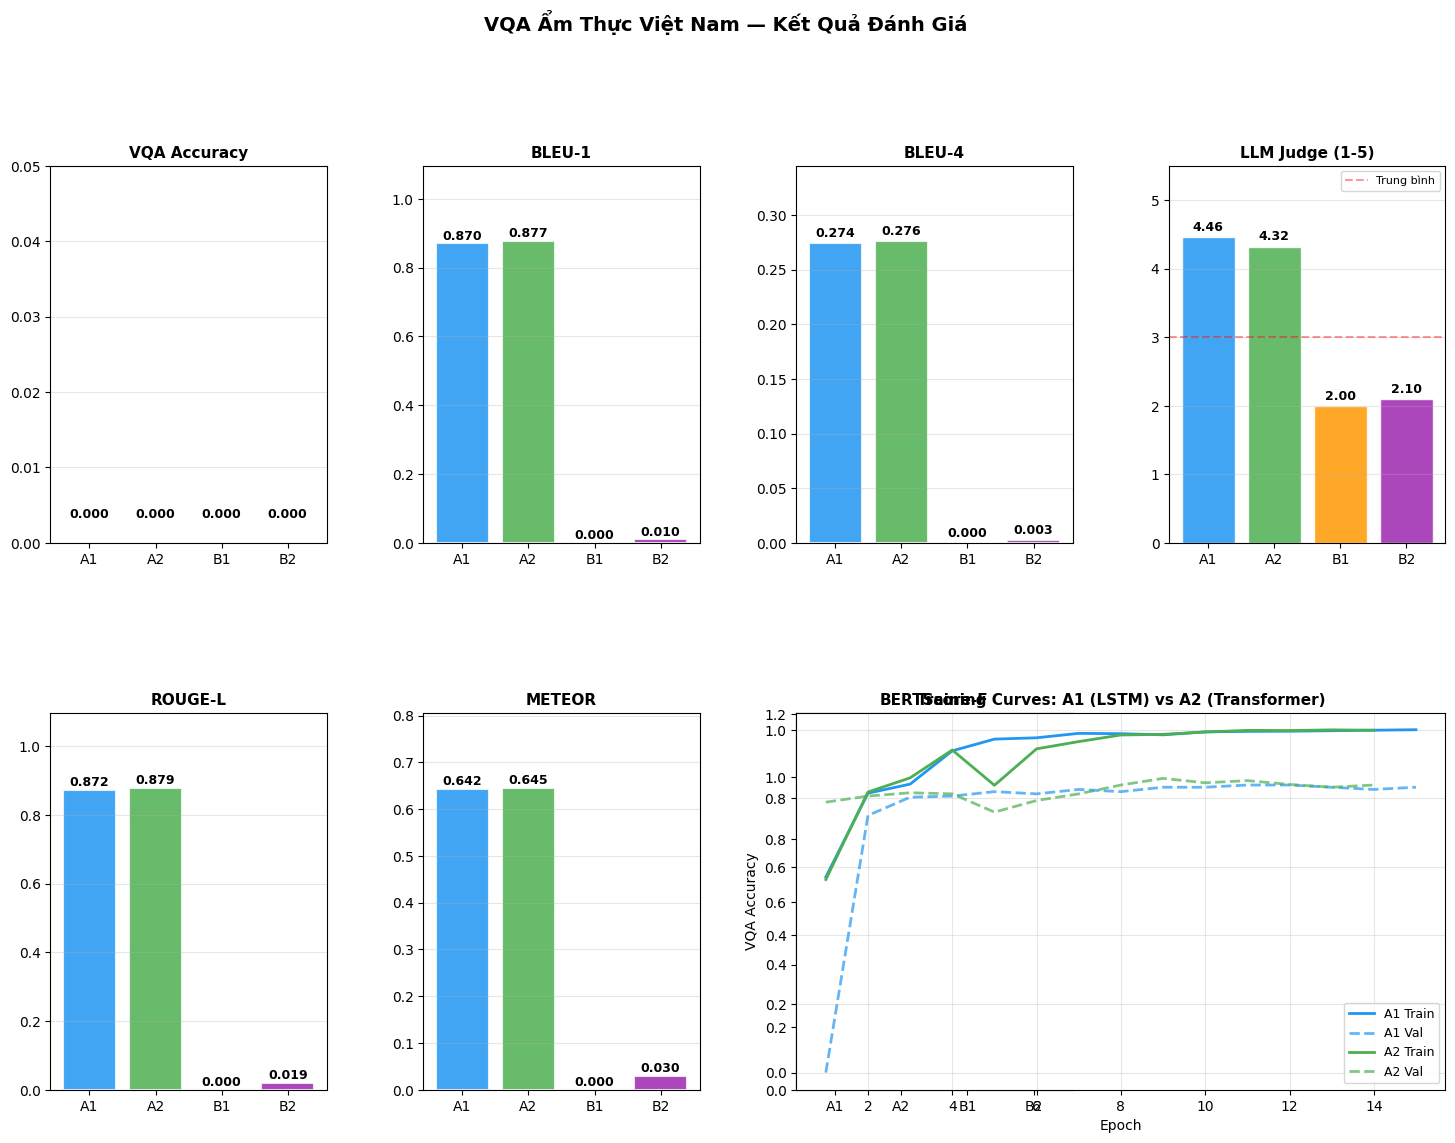

✅ Biểu đồ lưu → results/comparison.png


In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — BẢNG KẾT QUẢ & BIỂU ĐỒ SO SÁNH (FIXED)
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── Results dir ───────────────────────────────────────────────
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Metrics ───────────────────────────────────────────────────
METRICS  = [
    'vqa_exact_match',
    'bleu_1',
    'bleu_4',
    'rouge_l',
    'meteor',
    'bertscore_f',
    'llm_judge'
]

M_LABELS = [
    'VQA Accuracy',
    'BLEU-1',
    'BLEU-4',
    'ROUGE-L',
    'METEOR',
    'BERTScore-F',
    'LLM Judge/5'
]

CFGS   = [k for k in ['A1','A2','B1','B2'] if k in RESULTS]
COLORS = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

# ═══════════════════════════════════════════════════════════════
# BẢNG KẾT QUẢ
# ═══════════════════════════════════════════════════════════════

print('\n' + '═'*72)
print('  SO SÁNH 4 CẤU HÌNH VQA — ẨM THỰC VIỆT NAM')
print('═'*72)

header = f'{"Metric":<18}' + ''.join(f'{c:>13}' for c in CFGS)
print(header)

print('─'*72)

for m, ml in zip(METRICS, M_LABELS):

    row = f'{ml:<18}'

    for c in CFGS:

        v = float(RESULTS.get(c, {}).get(m, 0))

        if m == 'llm_judge':
            row += f'{v:>13.2f}'
        else:
            row += f'{v:>13.4f}'

    print(row)

print('═'*72)

# ═══════════════════════════════════════════════════════════════
# LSTM vs Transformer
# ═══════════════════════════════════════════════════════════════

if 'A1' in RESULTS and 'A2' in RESULTS:

    a1a = float(RESULTS['A1'].get('vqa_exact_match', 0))
    a2a = float(RESULTS['A2'].get('vqa_exact_match', 0))

    winner = 'A2 (Transformer)' if a2a > a1a else 'A1 (LSTM)'

    print(
        f'\n▶ LSTM vs Transformer: {winner} tốt hơn '
        f'{abs(a2a-a1a)*100:.2f}% VQA Accuracy'
    )

print()

# ═══════════════════════════════════════════════════════════════
# BIỂU ĐỒ
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18,12))

gs = gridspec.GridSpec(
    2, 4,
    hspace=0.45,
    wspace=0.35
)

# ── 1) Metrics bars ───────────────────────────────────────────
for i, (m, ml) in enumerate(
    list(zip(METRICS[:-1], M_LABELS[:-1]))
):

    ax = fig.add_subplot(gs[i//3, i%3])

    vals = [
        float(RESULTS.get(c, {}).get(m, 0))
        for c in CFGS
    ]

    bars = ax.bar(
        CFGS,
        vals,
        color=COLORS[:len(CFGS)],
        alpha=0.85,
        edgecolor='white',
        linewidth=1.5
    )

    ax.set_title(
        ml,
        fontweight='bold',
        fontsize=11
    )

    ymax = max(max(vals)*1.25, 0.05)

    ax.set_ylim(0, ymax)

    ax.grid(axis='y', alpha=0.3)

    for bar, v in zip(bars, vals):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{v:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

# ── 2) LLM Judge ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0,3])

vals = [
    float(RESULTS.get(c, {}).get('llm_judge', 0))
    for c in CFGS
]

bars = ax.bar(
    CFGS,
    vals,
    color=COLORS[:len(CFGS)],
    alpha=0.85,
    edgecolor='white'
)

ax.set_title(
    'LLM Judge (1-5)',
    fontweight='bold',
    fontsize=11
)

ax.set_ylim(0, 5.5)

ax.axhline(
    3,
    color='red',
    linestyle='--',
    alpha=0.4,
    label='Trung bình'
)

ax.grid(axis='y', alpha=0.3)

ax.legend(fontsize=8)

for bar, v in zip(bars, vals):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{v:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# ── 3) Training Curves ───────────────────────────────────────
ax = fig.add_subplot(gs[1,2:])

clr_map = {
    'A1':'#2196F3',
    'A2':'#4CAF50'
}

for t_name, trainer in [('A1', TRAINER_A1), ('A2', TRAINER_A2)]:

    if not hasattr(trainer, 'history'):
        continue

    h = trainer.history

    if 'val_acc' not in h or 'train_acc' not in h:
        continue

    ep = range(1, len(h['val_acc'])+1)

    c = clr_map[t_name]

    ax.plot(
        ep,
        h['train_acc'],
        color=c,
        linewidth=2,
        label=f'{t_name} Train'
    )

    ax.plot(
        ep,
        h['val_acc'],
        color=c,
        linewidth=2,
        linestyle='--',
        alpha=0.7,
        label=f'{t_name} Val'
    )

ax.set_title(
    'Training Curves: A1 (LSTM) vs A2 (Transformer)',
    fontweight='bold',
    fontsize=11
)

ax.set_xlabel('Epoch')

ax.set_ylabel('VQA Accuracy')

ax.legend(fontsize=9)

ax.grid(alpha=0.3)

# ── Save ──────────────────────────────────────────────────────
fig.suptitle(
    'VQA Ẩm Thực Việt Nam — Kết Quả Đánh Giá',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.savefig(
    f'{RESULTS_DIR}/comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f'✅ Biểu đồ lưu → {RESULTS_DIR}/comparison.png')

## CELL 18 — Demo: đặt câu hỏi về ảnh bất kỳ

📷 Ảnh: /content/drive/MyDrive/DL/dataset_small/train/Canh chua/696.jpg
🍜 Món: Canh chua



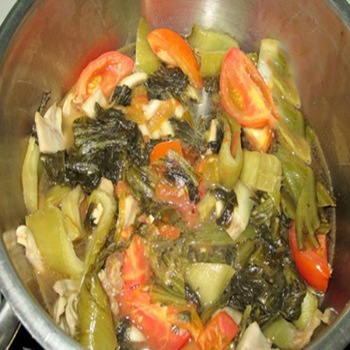

Text(value='Đây là món gì?', description='Question:', layout=Layout(width='600px'), placeholder='Nhập câu hỏi.…

Dropdown(description='Model:', index=1, options=('A1', 'A2', 'B1', 'B2'), value='A2')

Button(button_style='success', description='Ask', style=ButtonStyle())

Output()


✅ Nhập câu hỏi rồi bấm Ask


In [26]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — INTERACTIVE DEMO VQA (FIXED)
# ═══════════════════════════════════════════════════════════════

from IPython.display import display
import ipywidgets as widgets

from PIL import Image as PILImage

import numpy as np
import torch
import random

# ═══════════════════════════════════════════════════════════════
# SAMPLE IMAGE
# ═══════════════════════════════════════════════════════════════

sample = random.choice(TEST_DATA)

demo_img_path = sample['image_path']

print(f'📷 Ảnh: {demo_img_path}')
print(f'🍜 Món: {sample["dish_label"]}')
print()

try:
    display(
        PILImage.open(demo_img_path).resize((350,350))
    )
except:
    print("(Không hiển thị được ảnh)")

# ═══════════════════════════════════════════════════════════════
# BLIP PREDICT
# ═══════════════════════════════════════════════════════════════

@torch.no_grad()
def blip_predict(
    images,
    questions,
    model,
    max_new_tokens=10
):

    model.eval()

    prompts = [
        f"Question: {q} Answer:"
        for q in questions
    ]

    inputs = PROCESSOR(
        images=images,
        text=prompts,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    outputs = model.generate(
        pixel_values=inputs["pixel_values"],
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        num_beams=3,
        do_sample=False
    )

    answers = PROCESSOR.batch_decode(
        outputs,
        skip_special_tokens=True
    )

    cleaned = []

    for a in answers:

        if "Answer:" in a:
            a = a.split("Answer:")[-1]

        cleaned.append(a.strip())

    return cleaned

# ═══════════════════════════════════════════════════════════════
# ASK FUNCTION
# ═══════════════════════════════════════════════════════════════

def ask(
    image_path,
    question,
    config='A2'
):

    img = PILImage.open(image_path).convert('RGB')

    img_np = np.array(img)

    # ═══════════════════════════════════════════════════════════
    # A1 / A2
    # ═══════════════════════════════════════════════════════════

    if config in ['A1', 'A2']:

        trainer = (
            TRAINER_A1
            if config == 'A1'
            else TRAINER_A2
        )

        trainer.model.eval()

        tfm = get_transforms('test')

        transformed = tfm(image=img_np)

        img_t = transformed['image']

        if not isinstance(img_t, torch.Tensor):
            img_t = torch.tensor(img_t)

        # HWC -> CHW
        if len(img_t.shape) == 3 and img_t.shape[-1] == 3:
            img_t = img_t.permute(2,0,1)

        img_t = img_t.unsqueeze(0).float().to(DEVICE)

        # encode question
        q_ids = Q_VOCAB.encode_question(question)

        # padding
        if len(q_ids) < MAX_Q_LEN:
            q_ids += [0] * (MAX_Q_LEN - len(q_ids))
        else:
            q_ids = q_ids[:MAX_Q_LEN]

        q_len = min(
            len(question.split()),
            MAX_Q_LEN
        )

        batch = {
            'image': img_t,
            'question_ids': torch.tensor([q_ids]).to(DEVICE),
            'question_len': torch.tensor([q_len]).to(DEVICE),
            'question_text': [question],
        }

        with torch.no_grad():

            ans = trainer.model.generate_text(batch)[0]

        return ans

    # ═══════════════════════════════════════════════════════════
    # B1
    # ═══════════════════════════════════════════════════════════

    elif config == 'B1':

        if 'BLIP_BASE' not in globals():
            return '[BLIP_BASE chưa load]'

        return blip_predict(
            [img],
            [question],
            BLIP_BASE
        )[0]

    # ═══════════════════════════════════════════════════════════
    # B2
    # ═══════════════════════════════════════════════════════════

    elif config == 'B2':

        if 'BLIP_FINE' not in globals():
            return '[BLIP_FINE chưa load]'

        return blip_predict(
            [img],
            [question],
            BLIP_FINE
        )[0]

    return ''

# ═══════════════════════════════════════════════════════════════
# UI
# ═══════════════════════════════════════════════════════════════

question_box = widgets.Text(
    value='Đây là món gì?',
    placeholder='Nhập câu hỏi...',
    description='Question:',
    layout=widgets.Layout(width='600px')
)

model_dropdown = widgets.Dropdown(
    options=['A1', 'A2', 'B1', 'B2'],
    value='A2',
    description='Model:'
)

ask_button = widgets.Button(
    description='Ask',
    button_style='success'
)

output_box = widgets.Output()

# ═══════════════════════════════════════════════════════════════
# BUTTON EVENT
# ═══════════════════════════════════════════════════════════════

def on_ask_clicked(b):

    with output_box:

        output_box.clear_output()

        q = question_box.value
        cfg = model_dropdown.value

        print(f'❓ Question: {q}')
        print(f'🤖 Model: {cfg}')
        print()

        try:

            ans = ask(
                demo_img_path,
                q,
                cfg
            )

            print(f'✅ Answer: {ans}')

        except Exception as e:

            print(f'❌ ERROR: {str(e)}')

ask_button.on_click(on_ask_clicked)

# ═══════════════════════════════════════════════════════════════
# DISPLAY
# ═══════════════════════════════════════════════════════════════

display(question_box)
display(model_dropdown)
display(ask_button)
display(output_box)

print("\n✅ Nhập câu hỏi rồi bấm Ask")